# Dev / test notebook for data labels and loading for DEAR

Need to make sure things are ok:
- interactive annotation + rush mean there's already issues I've found
- amending DEAR's data loading to be less 'research-grade' but need to make sure not breaking things in the process


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import logging
import torch 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

sys.path.append('..')

import src.data_utils as dut
import src.plotting as splo

import src.dear.utils as sdu
import src.dear.data as sdd

## Set up namespace, e.g. point to data

In [3]:
config_dict = {
    'data_root' : '../data/',
    'dataset' : 'xView_0',
    'label_file': 'labels.csv',
    'batch_size' : 15,
    'normalize': False,
    'add_flips': False,
    'labels_index': ['buildings','roads','cars'],
    'image_size': 64,
    'sup_prop': 1,
}
args = sdu.DummyArgs( config_dict)
args.data_dir = f'{args.data_root}{args.dataset}'

In [4]:
def image_x_y_from_str( str_):
    x_ = str_.split('x')[1].split('_')[0].split('.')[0]
    y_ = str_.split('y')[1].split('_')[0].split('.')[0]
    im_ = str_.split('tif')[1].split('_')[0]
    return im_, x_, y_

def plot_batch_of_15( x, labels, names):
    f, axs = plt.subplots( ncols= 3, nrows= 5, figsize= (9,15),)
    axs = axs.reshape(-1)
    for ii, im in enumerate( x):
        im_ar = dut.to_numpy( im)
        min_, max_ = int(im_ar.min()), int(im_ar.max())
        axs[ii].imshow( im_ar)
        axs[ii].get_xaxis().set_visible(False)
        axs[ii].get_yaxis().set_visible(False)
        b_, r_, c_ = [int(x) for x in labels[ ii].numpy()]
        if b_!=-1:
            title = f'b{b_} r{r_} c{c_}, {min_}-{max_}'
        else:
            title = f'         , {min_}-{max_}'
        im_,x_,y_ = image_x_y_from_str( names[ ii])
        title += f'\ntif{im_}_x{x_}_y{y_}'
        axs[ii].set_title( title, fontsize= 10)
    return f

### check out data loader etc

In [5]:
data_loader, _ = sdd.make_dataloader( args)

Loaded labels from ../data/xView_0\labels.csv, total of 8172 entries.
First entry: tif102_x65_y1613.png, with labels [-1. -1. -1.]


In [7]:
x, labels, names = sdd.get_batch_no( data_loader, 0)
if args.normalize:
    x = [sdu.denorm( im) for im in x]
x.shape, labels.shape

In batch 0 there are 4 supervised.


(torch.Size([15, 3, 64, 64]), torch.Size([15, 3]))

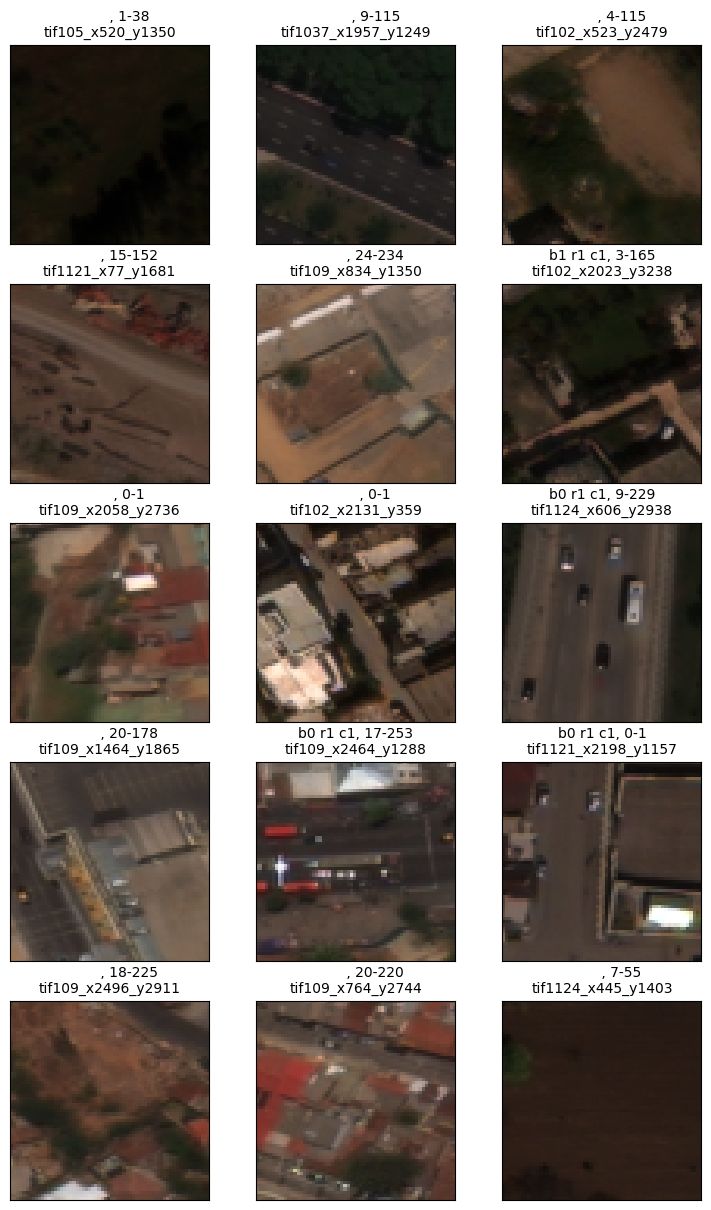

In [8]:
_ = plot_batch_of_15( x, labels, names)

In [10]:
out_dir = f'{args.data_dir}sanity_checks/'
os.makedirs( out_dir, exist_ok= True)

for batch_idx, (x, labels, names) in enumerate( data_loader):
    if args.normalize:
        x = [sdu.denorm( im) for im in x]
    f = plot_batch_of_15( x, labels, names)
    f.savefig(f'{out_dir}batch_{batch_idx}.png', dpi= 300, bbox_inches= 'tight')
    plt.close()

In [25]:
im_to_check = 'tif109_x296_y1534.png'

In [50]:
df = pd.read_csv('../data/xView_0/labels/for_tiff109.csv')

In [51]:
df.loc[ df['xs']==296]

,xs,ys,bbox_np,bbox_context,bbox_in_context,built_area,n_cars,n_bus_trucks,roads,im_name,labels
44,296,1534,"[232, 1470, 360, 1598]","[168, 1406, 424, 1662]","[64, 64, 192, 192]",0.0,0.0,0.0,1.0,109_90.png,road


In [77]:
df_ = pd.read_csv('../data/xView_0_fix/labels.csv')

In [78]:
df_.loc[df_.image== 'tif109_x296_y1534.png']

,image,xs,ys,bbox_np,buildings,roads,cars,B_R_C
5002,tif109_x296_y1534.png,296,1534,"[232, 1470, 360, 1598]",0,1,0,10.0


In [70]:
dataset_0 = sdd.DatasetLabelled( args.data_dir, 128, args.label_file, args.labels_index, normalize= False)
dataset_1 = sdd.DatasetLabelled( f'{args.data_dir}_fix', 128, args.label_file, args.labels_index, normalize= False)

Loaded labels from ../data/xView_0\labels.csv, total of 8172 entries.
First entry: tif102_x65_y1613.png, with labels [-1. -1. -1.]
Loaded labels from ../data/xView_0_fix\labels.csv, total of 8176 entries.
First entry: tif102_x65_y1613.png, with labels [-1 -1 -1]


In [71]:
ii_0 = [ii for ii, x in enumerate(dataset_0.image_names) if x==im_to_check][0]
ii_1 = [ii for ii, x in enumerate(dataset_1.image_names) if x==im_to_check][0]

In [72]:
dataset_1.labels[ii_1].astype(float)

array([0., 1., 0.])

In [76]:
im_0, l_0, _ = dataset_0.__getitem__( ii_0)
im_1, l_1, _ = dataset_1.__getitem__( ii_1)

Text(0.5, 1.0, 'tensor([0., 1., 0.], dtype=torch.float64)')

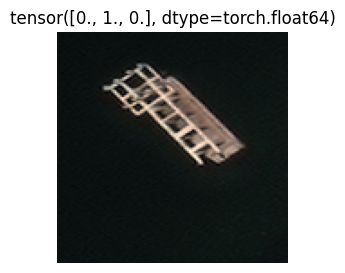

In [74]:
ax = splo.plot_single( dut.to_numpy( im_0), figsize= (3,3))
ax.set_title( str(l_0))

Text(0.5, 1.0, 'tensor([0., 1., 0.], dtype=torch.float64)')

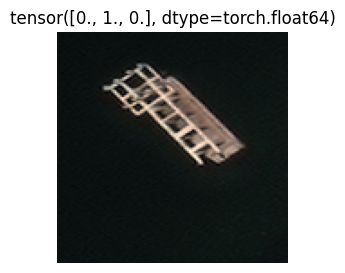

In [75]:
ax = splo.plot_single( dut.to_numpy( im_1), figsize= (3,3))
ax.set_title( str(l_1))

In [37]:
l_0

tensor([0., 1., 0.], dtype=torch.float64)

In [44]:
def filt_( dataset, name_f, label_f):
    return [
        ii for ii, (n, l) in enumerate( zip( dataset.image_names, dataset.labels)) if name_f( n) and label_f( l)
    ]

name_cond = lambda x: x.startswith('tif109')
label_cond = lambda x: x[0]!=-1

In [45]:
check0 = filt_( dataset_0, name_cond, label_cond)
check1 = filt_( dataset_1, name_cond, label_cond)

In [46]:
len(check0)

281

In [47]:
len(check1)

281

In [48]:
dataset_0.__getitem__(check0[0])

(tensor([[[0.6706, 0.7412, 0.7765,  ..., 0.3137, 0.3098, 0.3098],
          [0.6314, 0.6980, 0.7412,  ..., 0.3098, 0.3137, 0.3137],
          [0.5843, 0.6235, 0.6824,  ..., 0.3176, 0.3098, 0.3137],
          ...,
          [0.2941, 0.3020, 0.3098,  ..., 0.3059, 0.2706, 0.2588],
          [0.2902, 0.2902, 0.2980,  ..., 0.2980, 0.2588, 0.2392],
          [0.2863, 0.3020, 0.3176,  ..., 0.2745, 0.2706, 0.2588]],
 
         [[0.5098, 0.5725, 0.6078,  ..., 0.2824, 0.2784, 0.2745],
          [0.4706, 0.5294, 0.5725,  ..., 0.2784, 0.2784, 0.2784],
          [0.4275, 0.4667, 0.5176,  ..., 0.2824, 0.2784, 0.2784],
          ...,
          [0.2431, 0.2510, 0.2549,  ..., 0.1922, 0.1686, 0.1608],
          [0.2431, 0.2392, 0.2431,  ..., 0.1882, 0.1608, 0.1490],
          [0.2392, 0.2510, 0.2588,  ..., 0.1765, 0.1725, 0.1647]],
 
         [[0.3725, 0.4314, 0.4706,  ..., 0.1843, 0.1804, 0.1804],
          [0.3451, 0.4000, 0.4431,  ..., 0.1804, 0.1843, 0.1843],
          [0.3098, 0.3451, 0.3961,  ...,